# Model Development Lab: Parallel Model Training with Ray

This notebook demonstrates a scalable model development workflow by benchmarking **sequential vs parallel** model training using **Ray**.  
It trains multiple candidate models over a hyperparameter grid, compares runtime and accuracy, and persists the best model as an artifact.

Key outcomes:
- Faster experimentation through parallel execution  
- Repeatable training & evaluation  
- Reproducible artifacts (`best_model.joblib`, `metrics.json`)  
- Visual insight into hyperparameter performance

In [1]:
# !pip install scikit-learn ray

In [2]:
import time
import json
from pathlib import Path
from operator import itemgetter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Ray (parallel compute)
import ray

## 1. Dataset Preparation

We use a supervised regression dataset and split it into train/test sets.  
The goal is to train many candidate models (hyperparameter variants) and compare:

- Model quality (MSE)
- Training time (wall-clock)
- Overall speedup with Ray

In [3]:
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
X_train.head()

Train shape: (16512, 8)  Test shape: (4128, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [4]:
# How many models to train (can be increase if one's machine can handle it)
NUM_MODELS = 24

# Build a small hyperparameter grid (not identical to professor's notebook)
# This is to sweep combinations of (n_estimators, max_depth, min_samples_leaf)
grid = []
for i in range(NUM_MODELS):
  n_estimators = 50 + (i % 8) * 50          # 50,100,...,400
  max_depth = [None, 10, 20][i % 3]         # None,10,20
  min_leaf = [1, 2][(i // 3) % 2]           # 1,2
  grid.append((n_estimators, max_depth, min_leaf))

grid[:5], len(grid)

([(50, None, 1), (100, 10, 1), (150, 20, 1), (200, None, 2), (250, 10, 2)], 24)

In [5]:
def train_and_score_model(
  train_set: pd.DataFrame,
  test_set: pd.DataFrame,
  train_labels: pd.Series,
  test_labels: pd.Series,
  n_estimators: int,
  max_depth,
  min_samples_leaf: int,
) -> dict:
  start = time.time()

  model = RandomForestRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf,
    random_state=42,
    n_jobs=1,  # important so Ray parallelism doesn't fight internal parallelism
  )

  model.fit(train_set, train_labels)
  preds = model.predict(test_set)

  mse = mean_squared_error(test_labels, preds)
  elapsed = time.time() - start

  return {
    "n_estimators": n_estimators,
    "max_depth": max_depth,
    "min_samples_leaf": min_samples_leaf,
    "mse": mse,
    "train_time_sec": elapsed,
  }

## 2. Sequential Baseline

We first train models **sequentially** to establish a baseline runtime.  
This provides a reference point to measure how much parallelism helps.

In [6]:
def run_sequential(param_grid) -> list[dict]:
  results = []
  
  for (n_estimators, max_depth, min_leaf) in param_grid:
    r = train_and_score_model(
      train_set=X_train,
      test_set=X_test,
      train_labels=y_train,
      test_labels=y_test,
      n_estimators=n_estimators,
      max_depth=max_depth,
      min_samples_leaf=min_leaf,
    )
    
    print(f"[SEQ] {r}")
    results.append(r)
  return results

In [7]:
t0 = time.time()
seq_results = run_sequential(grid)
seq_time = time.time() - t0

print(f"\n✅ Sequential run completed in {seq_time:.2f} seconds")

[SEQ] {'n_estimators': 50, 'max_depth': None, 'min_samples_leaf': 1, 'mse': 0.25640977987111035, 'train_time_sec': 2.8884098529815674}
[SEQ] {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 1, 'mse': 0.29647453265996826, 'train_time_sec': 3.6536879539489746}
[SEQ] {'n_estimators': 150, 'max_depth': 20, 'min_samples_leaf': 1, 'mse': 0.2550377130170709, 'train_time_sec': 8.092932939529419}
[SEQ] {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'mse': 0.2540673025273546, 'train_time_sec': 10.301002979278564}
[SEQ] {'n_estimators': 250, 'max_depth': 10, 'min_samples_leaf': 2, 'mse': 0.29312320173942735, 'train_time_sec': 9.248292684555054}
[SEQ] {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 2, 'mse': 0.2539166357028084, 'train_time_sec': 15.188569068908691}
[SEQ] {'n_estimators': 350, 'max_depth': None, 'min_samples_leaf': 1, 'mse': 0.25258576701667573, 'train_time_sec': 19.71510100364685}
[SEQ] {'n_estimators': 400, 'max_depth': 10, 'min_samples_leaf'

In [8]:
best_seq = min(seq_results, key=lambda d: d["mse"])
print("✅ Best (Sequential):", best_seq)

pd.DataFrame(seq_results).sort_values("mse").head(10)

✅ Best (Sequential): {'n_estimators': 350, 'max_depth': None, 'min_samples_leaf': 1, 'mse': 0.25258576701667573, 'train_time_sec': 19.71510100364685}


,n_estimators,max_depth,min_samples_leaf,mse,train_time_sec
6,350,NaN,1,0.252586,19.715101
12,250,NaN,1,0.253187,14.098791
23,400,20.0,2,0.253206,20.250913
14,350,20.0,1,0.253309,19.632025
15,400,NaN,2,0.253333,20.578647
20,250,20.0,1,0.253789,13.554164
5,300,20.0,2,0.253917,15.188569
11,200,20.0,2,0.253975,10.201765
21,300,NaN,2,0.253992,15.333425
3,200,NaN,2,0.254067,10.301003


## 3. Ray Parallel Implementation

Ray enables distributed execution using:
- `ray.init()` to start a runtime
- `ray.put()` to store shared objects in the object store
- `@ray.remote` to define tasks
- `ray.get()` to collect results

This allows multiple models to train concurrently.

In [9]:
if ray.is_initialized():
  ray.shutdown()

ray.init(ignore_reinit_error=True)

print("✅ Ray initialized")
print("Ray resources:", ray.cluster_resources())

2026-02-27 15:49:03,188	INFO worker.py:2013 -- Started a local Ray instance.


✅ Ray initialized
Ray resources: {'object_store_memory': 2147483648.0, 'node:127.0.0.1': 1.0, 'memory': 6657753088.0, 'node:__internal_head__': 1.0, 'CPU': 8.0}


/Users/aryan/Desktop/Aryan/Studies/Northeastern/Spring 2026/MLOps/.venv/lib/python3.12/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [10]:
X_train_ref = ray.put(X_train)
X_test_ref = ray.put(X_test)
y_train_ref = ray.put(y_train)
y_test_ref = ray.put(y_test)

print("✅ Data placed in Ray object store")
print("Example object ref:", X_train_ref)

✅ Data placed in Ray object store
Example object ref: ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000001e1f505)


In [11]:
@ray.remote
def train_and_score_model_remote(
  train_set_ref,
  test_set_ref,
  train_labels_ref,
  test_labels_ref,
  n_estimators: int,
  max_depth,
  min_samples_leaf: int,
) -> dict:
  start = time.time()

  model = RandomForestRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf,
    random_state=42,
    n_jobs=1,
  )

  model.fit(train_set_ref, train_labels_ref)
  preds = model.predict(test_set_ref)
  mse = mean_squared_error(test_labels_ref, preds)

  return {
    "n_estimators": n_estimators,
    "max_depth": max_depth,
    "min_samples_leaf": min_samples_leaf,
    "mse": mse,
    "train_time_sec": time.time() - start,
  }

In [12]:
def run_parallel(param_grid) -> list[dict]:
  futures = []
  
  for (n_estimators, max_depth, min_leaf) in param_grid:
    fut = train_and_score_model_remote.remote(
      train_set_ref=X_train_ref,
      test_set_ref=X_test_ref,
      train_labels_ref=y_train_ref,
      test_labels_ref=y_test_ref,
      n_estimators=n_estimators,
      max_depth=max_depth,
      min_samples_leaf=min_leaf,
    )
    futures.append(fut)

  results = ray.get(futures)
  return results

## 4. Benchmark Results & Speedup

We compare total sequential time vs parallel time and compute:

$$
\text{Speedup} = \frac{T_{sequential}}{T_{parallel}}
$$

A speedup > 1 indicates the parallel approach is faster.

In [13]:
t0 = time.time()
par_results = run_parallel(grid)
par_time = time.time() - t0

best_par = min(par_results, key=lambda d: d["mse"])

speedup = seq_time / par_time if par_time > 0 else float("inf")

print(f"✅ Parallel run completed in {par_time:.2f} seconds")
print(f"🚀 Speedup: {speedup:.2f}x")
print("✅ Best (Parallel):", best_par)

pd.DataFrame(par_results).sort_values("mse").head(10)

✅ Parallel run completed in 58.84 seconds
🚀 Speedup: 4.39x
✅ Best (Parallel): {'n_estimators': 350, 'max_depth': None, 'min_samples_leaf': 1, 'mse': 0.25258576701667573, 'train_time_sec': 28.484034061431885}


,n_estimators,max_depth,min_samples_leaf,mse,train_time_sec
6,350,NaN,1,0.252586,28.484034
12,250,NaN,1,0.253187,20.365439
23,400,20.0,2,0.253206,24.075846
14,350,20.0,1,0.253309,27.649419
15,400,NaN,2,0.253333,29.002257
20,250,20.0,1,0.253789,18.908104
5,300,20.0,2,0.253917,21.552419
11,200,20.0,2,0.253975,14.406790
21,300,NaN,2,0.253992,20.570595
3,200,NaN,2,0.254067,14.266202


In [14]:
# Benchmark summary table - Addition
summary = pd.DataFrame([
  {"method": "sequential", "total_time_sec": seq_time, "best_mse": best_seq["mse"]},
  {"method": "ray_parallel", "total_time_sec": par_time, "best_mse": best_par["mse"]},
])

summary["speedup_x"] = summary["total_time_sec"].iloc[0] / summary["total_time_sec"]
summary

,method,total_time_sec,best_mse,speedup_x
0,sequential,258.084843,0.252586,1.000000
1,ray_parallel,58.840509,0.252586,4.386176


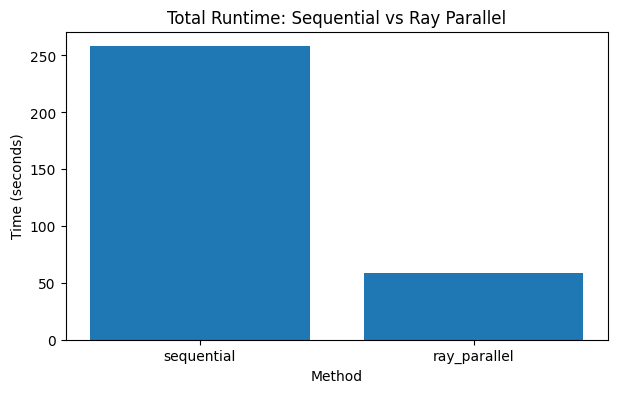

✅ Speedup (seq/par): 4.39x


In [15]:
# Speed comparison plot - Addition
plt.figure(figsize=(7, 4))
plt.bar(summary["method"], summary["total_time_sec"])
plt.title("Total Runtime: Sequential vs Ray Parallel")
plt.xlabel("Method")
plt.ylabel("Time (seconds)")
plt.show()

print(f"✅ Speedup (seq/par): {speedup:.2f}x")

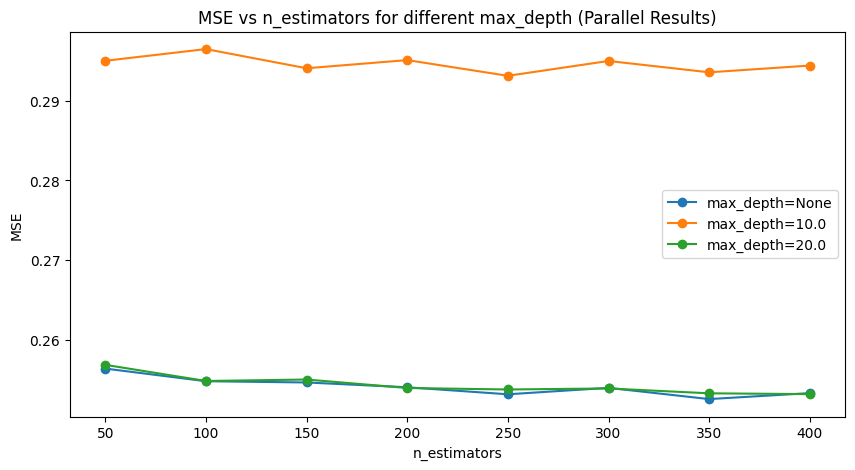

In [16]:
df = pd.DataFrame(par_results).copy()

# For plotting, replace None depth with a string label
df["max_depth_plot"] = df["max_depth"].astype("object").fillna("None")

plt.figure(figsize=(10, 5))
for depth in df["max_depth_plot"].unique():
  subset = df[df["max_depth_plot"] == depth].sort_values("n_estimators")
  plt.plot(subset["n_estimators"], subset["mse"], marker="o", label=f"max_depth={depth}")

plt.title("MSE vs n_estimators for different max_depth (Parallel Results)")
plt.xlabel("n_estimators")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [17]:
# Top 5 configs - Lowest MSE
top5 = df.sort_values("mse").head(5)
top5

,n_estimators,max_depth,min_samples_leaf,mse,train_time_sec,max_depth_plot
6,350,NaN,1,0.252586,28.484034,None
12,250,NaN,1,0.253187,20.365439,None
23,400,20.0,2,0.253206,24.075846,20.0
14,350,20.0,1,0.253309,27.649419,20.0
15,400,NaN,2,0.253333,29.002257,None


## 5. Artifact Saving (MLOps Addition)

To make the workflow reproducible, we retrain the best configuration and save:
- The trained model (`artifacts/best_model.joblib`)
- Metrics and benchmark timings (`artifacts/metrics.json`)
- Benchmark Summary (`artifacts/benchmark_summary.csv`)

This mirrors a real model development workflow where experiments produce persistent outputs.

In [18]:
import joblib

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

best_cfg = best_par

final_model = RandomForestRegressor(
  n_estimators=best_cfg["n_estimators"],
  max_depth=best_cfg["max_depth"],
  min_samples_leaf=best_cfg["min_samples_leaf"],
  random_state=42,
  n_jobs=1,
)

final_model.fit(X_train, y_train)
final_preds = final_model.predict(X_test)
final_mse = mean_squared_error(y_test, final_preds)

joblib.dump(final_model, artifacts_dir / "best_model.joblib")

metrics = {
  "best_config": best_cfg,
  "final_mse": final_mse,
  "sequential_time_sec": seq_time,
  "parallel_time_sec": par_time,
  "speedup_x": speedup,
  "dataset": "fetch_california_housing",
  "model": "RandomForestRegressor",
}

with open(artifacts_dir / "metrics.json", "w") as f:
  json.dump(metrics, f, indent=2)

print("✅ Saved:", artifacts_dir / "best_model.joblib")
print("✅ Saved:", artifacts_dir / "metrics.json")
print(f"✅ Final MSE (retrained best): {final_mse:.4f}")

✅ Saved: artifacts/best_model.joblib
✅ Saved: artifacts/metrics.json
✅ Final MSE (retrained best): 0.2526


In [19]:
# Save a benchmark summary created using the benchmark summary code after the speedup comparison to the artifacts folder
summary.to_csv(artifacts_dir / "benchmark_summary.csv", index=False)
print("✅ Saved:", artifacts_dir / "benchmark_summary.csv")

✅ Saved: artifacts/benchmark_summary.csv


## 6. Model Validation (Extra)

In addition to MSE, we visualize residuals to sanity-check prediction quality.  
This provides a simple diagnostic view of error distribution.

Residual summary:
  mean: -0.012271004872645912
  std : 0.5024292880158274
  min : -3.0229894000000006
  max : 3.1335527999999977


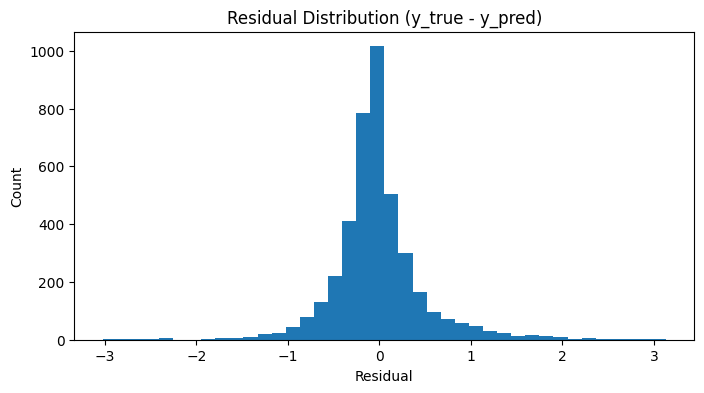

In [20]:
residuals = (y_test - final_preds).to_numpy()

print("Residual summary:")
print("  mean:", residuals.mean())
print("  std :", residuals.std())
print("  min :", residuals.min())
print("  max :", residuals.max())

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=40)
plt.title("Residual Distribution (y_true - y_pred)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

In [21]:
ray.shutdown()
print("✅ Ray shutdown complete")

✅ Ray shutdown complete
